### Importación de datos



In [141]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [142]:
tiendas =[tienda,tienda2,tienda3,tienda4]
ingresos=[(t['Precio'].sum())for t in tiendas]
for i , ingreso in enumerate(ingresos,start=1):
  print(f"Ingreso Tienda {i}: {ingreso}")

Ingreso Tienda 1: 1150880400.0
Ingreso Tienda 2: 1116343500.0
Ingreso Tienda 3: 1098019600.0
Ingreso Tienda 4: 1038375700.0


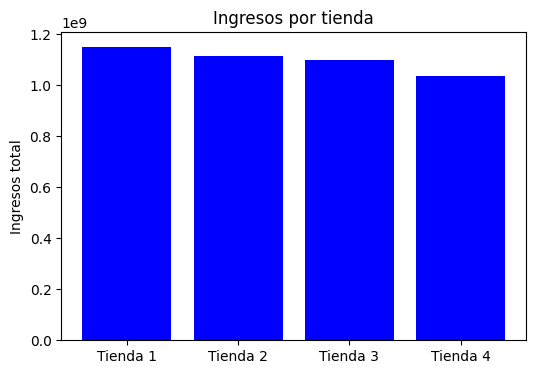

In [143]:
tiendas_nombres = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']
plt.figure(figsize=(6,4))
plt.bar(tiendas_nombres,ingresos, color='blue')
plt.title("Ingresos por tienda")
plt.ylabel("Ingresos total")
plt.show()

# 2. Ventas por categoría

In [144]:
tiendas =[tienda,tienda2,tienda3,tienda4]
for i , t in enumerate(tiendas,start=1):
  print(f"\nTienda {i}")
  print(t['Categoría del Producto'].value_counts())


Tienda 1
Categoría del Producto
Muebles                    465
Electrónicos               448
Juguetes                   324
Electrodomésticos          312
Deportes y diversión       284
Instrumentos musicales     182
Libros                     173
Artículos para el hogar    171
Name: count, dtype: int64

Tienda 2
Categoría del Producto
Muebles                    442
Electrónicos               422
Juguetes                   313
Electrodomésticos          305
Deportes y diversión       275
Instrumentos musicales     224
Libros                     197
Artículos para el hogar    181
Name: count, dtype: int64

Tienda 3
Categoría del Producto
Muebles                    499
Electrónicos               451
Juguetes                   315
Electrodomésticos          278
Deportes y diversión       277
Libros                     185
Instrumentos musicales     177
Artículos para el hogar    177
Name: count, dtype: int64

Tienda 4
Categoría del Producto
Muebles                    480
Electrónicos   

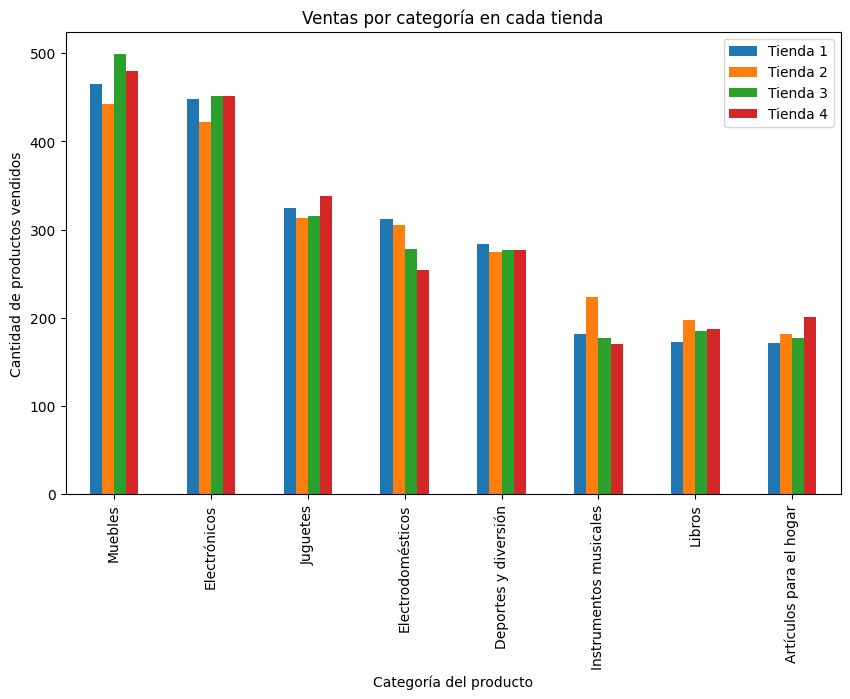

In [145]:
tiendas_nombres = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']
categorias = pd.concat([t['Categoría del Producto'].value_counts() for t in tiendas], axis=1)
categorias.columns = tiendas_nombres
categorias = categorias.fillna(0)
categorias.plot(kind='bar', figsize=(10,6))
plt.title("Ventas por categoría en cada tienda")
plt.ylabel("Cantidad de productos vendidos")
plt.xlabel("Categoría del producto")
plt.show()


# 3. Calificación promedio de la tienda


In [146]:
tiendas =[tienda,tienda2,tienda3,tienda4]
valoraciones=[t['Calificación'].mean() for t in tiendas]
for i, v in enumerate(valoraciones,start=1):
  print(f"Valoración promedio Tienda {i}: {v}")

Valoración promedio Tienda 1: 3.976685036032217
Valoración promedio Tienda 2: 4.037303942348453
Valoración promedio Tienda 3: 4.048325561678677
Valoración promedio Tienda 4: 3.9957591178965224


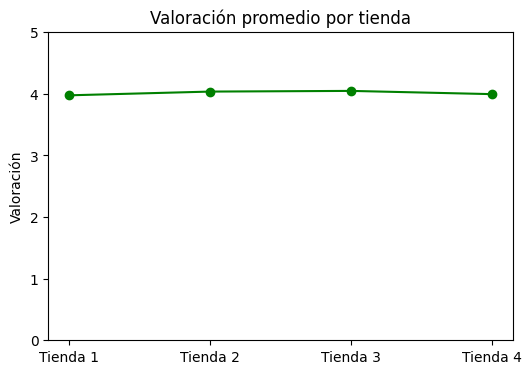

In [147]:
tiendas_nombres = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']
plt.figure(figsize=(6,4))
plt.plot(tiendas_nombres, valoraciones, marker='o', color='green')
plt.title("Valoración promedio por tienda")
plt.ylabel("Valoración")
plt.ylim(0,5)
plt.show()


# 4. Productos más y menos vendidos

In [148]:
tiendas =[tienda,tienda2,tienda3,tienda4]

productosMas = []
productosMenos = []
cantMas = []
cantMenos = []

for i, t in enumerate(tiendas, start=1):
  conteo=t['Producto'].value_counts()
  productosMas.append(conteo.idxmax())
  productosMenos.append(conteo.idxmin())
  cantMas.append(conteo.max())
  cantMenos.append(conteo.min())

  masVendido= conteo.idxmax()
  menosVendido=conteo.idxmin()

  print(f"\nTienda{i}")
  print("Producto mas vendido:", masVendido)
  print("Producto menos vendido:", menosVendido)


Tienda1
Producto mas vendido: Microondas
Producto menos vendido: Auriculares con micrófono

Tienda2
Producto mas vendido: Iniciando en programación
Producto menos vendido: Juego de mesa

Tienda3
Producto mas vendido: Kit de bancas
Producto menos vendido: Bloques de construcción

Tienda4
Producto mas vendido: Cama box
Producto menos vendido: Guitarra eléctrica


# 5. Envío promedio por tienda

In [149]:
tiendas =[tienda,tienda2,tienda3,tienda4]
for i, t in enumerate(tiendas, start=1):
  promedioEnvio= t['Costo de envío'].mean()
  print(f"Tienda {i}: {promedioEnvio}")

Tienda 1: 26018.60958033065
Tienda 2: 25216.235693090293
Tienda 3: 24805.680373039424
Tienda 4: 23459.457167090754
